# Model Training

### 1.1 Import Data and Required Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error

In [3]:
df = pd.read_csv('stud.csv')

In [4]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Preparing X and Y variables

In [9]:
x = df.drop(columns=['math_score'], axis =1)

In [10]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
print('Categories in Gender variable:', df['gender'].unique())
print('Categories in Race ethnicity variable:', df['race_ethnicity'].unique())
print('Categories in Parental level of education variable:', df['parental_level_of_education'].unique())
print('Categories in Lunch variable:', df['lunch'].unique())
print('Categories in Test preparation course variable:', df['test_preparation_course'].unique())


Categories in Gender variable: ['female' 'male']
Categories in Race ethnicity variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in Parental level of education variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in Lunch variable: ['standard' 'free/reduced']
Categories in Test preparation course variable: ['none' 'completed']


In [11]:
y = df['math_score']

In [12]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

### Create Column Transformer with 3 types of transformers

In [15]:
numerical_features = x.select_dtypes(exclude='object').columns
categorical_features = x.select_dtypes(include='object').columns

numeric_transformer = StandardScaler()
category_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=
[
    ("StandardScaler",numeric_transformer,numerical_features),
    ("OneHotEncoder",category_transformer,categorical_features)
]
                                )




In [16]:
x = preprocessor.fit_transform(x)

In [17]:
x.shape

(1000, 19)

In [19]:
# separate data into train and test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20, random_state =42)
x_train.shape,x_test.shape

((800, 19), (200, 19))

### Create an evaluation model to give all metric after model training

In [27]:
def evaluate_model(true,predicted):
    mse = mean_squared_error(true,predicted)
    mae = mean_absolute_error(true,predicted)
    rmse = root_mean_squared_error(true,predicted)
    r2 = r2_score(true,predicted)

    return mse,mae,rmse,r2

In [31]:
models={
       "Linear Regression": LinearRegression(),
       "Ridge":Ridge(),
       "Lasso":Lasso(),
       "KNN":KNeighborsRegressor(),
       "SVR":SVR(),
       "Decision Tree Regressor":DecisionTreeRegressor(),
       "Random Forest Regressor":RandomForestRegressor(),
       "Ada Boost Regressor":AdaBoostRegressor(),
       "XG Boost Regressor": XGBRegressor(),
       "Cat boosting Regressor": CatBoostRegressor()   
      }

models_list=[]
r2_list=[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Evaluate Train and Test Dataset
    model_train_mse, model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mse, model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    models_list.append(list(models.keys())[i])

    print('Model performance for training set')
    
    print("-R2 score: {:.4f}".format(model_train_r2))
    print("-Root Mean squared error: {:.4f}".format(model_train_rmse))
    print("-Mean absolute error: {:.4f}".format(model_train_mae))
    print("-Mean squared error: {:.4f}".format(model_train_mse))

    print('----------------------------------')
    
    
    print('Model performance for test set')
    
    print("-R2 score: {:.4f}".format(model_test_r2))
    print("-Root Mean squared error: {:.4f}".format(model_test_rmse))
    print("-Mean absolute error: {:.4f}".format(model_test_mae))
    print("-Mean squared error: {:.4f}".format(model_test_mse))

    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for training set
-R2 score: 0.8743
-Root Mean squared error: 5.3231
-Mean absolute error: 4.2667
-Mean squared error: 28.3349
----------------------------------
Model performance for test set
-R2 score: 0.8804
-Root Mean squared error: 5.3940
-Mean absolute error: 4.2148
-Mean squared error: 29.0952


Ridge
Model performance for training set
-R2 score: 0.8743
-Root Mean squared error: 5.3233
-Mean absolute error: 4.2650
-Mean squared error: 28.3378
----------------------------------
Model performance for test set
-R2 score: 0.8806
-Root Mean squared error: 5.3904
-Mean absolute error: 4.2111
-Mean squared error: 29.0563


Lasso
Model performance for training set
-R2 score: 0.8071
-Root Mean squared error: 6.5938
-Mean absolute error: 5.2063
-Mean squared error: 43.4783
----------------------------------
Model performance for test set
-R2 score: 0.8253
-Root Mean squared error: 6.5197
-Mean absolute error: 5.1579
-Mean squared error: 42.5063


KNN
Mod

### Results

In [36]:
pd.DataFrame(list(zip(models_list, r2_list)),columns = ['Model_name','R2_score']).sort_values(by='R2_score',ascending = False)

,Model_name,R2_score
1,Ridge,0.880593
0,Linear Regression,0.880433
9,Cat boosting Regressor,0.851632
6,Random Forest Regressor,0.851571
7,Ada Boost Regressor,0.848309
2,Lasso,0.825320
8,XG Boost Regressor,0.821221
3,KNN,0.783770
5,Decision Tree Regressor,0.754889
4,SVR,0.728600


## Linear Regression

In [37]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


### Plot y_test and y_pred

Text(0, 0.5, 'Predicted')

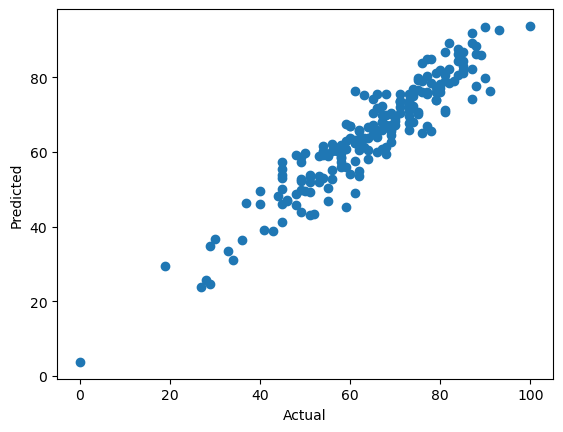

In [39]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math_score'>

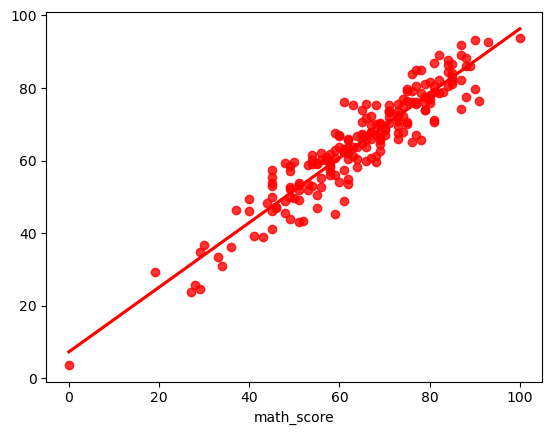

In [40]:
sns.regplot(x=y_test,y=y_pred, ci =None, color='Red')

### Difference Between Actual and Predicted Values

In [41]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred,'Difference': y_test-y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
